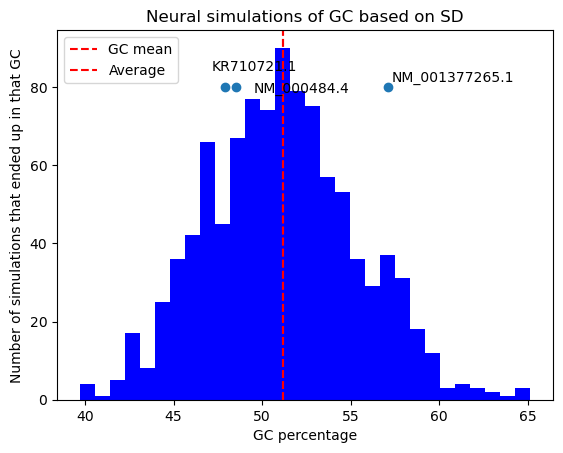

Mean: 51.16078419131399
The standard deviation is around 4.2036475764865235 points
The max gc is: 57.09464416727806
The min gc is: 47.88087056128293
<class 'numpy.ndarray'>
float64
[57.09464417 48.50683785 47.88087056]


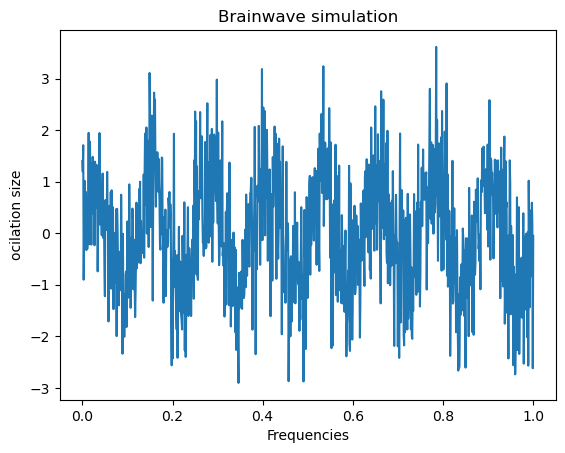

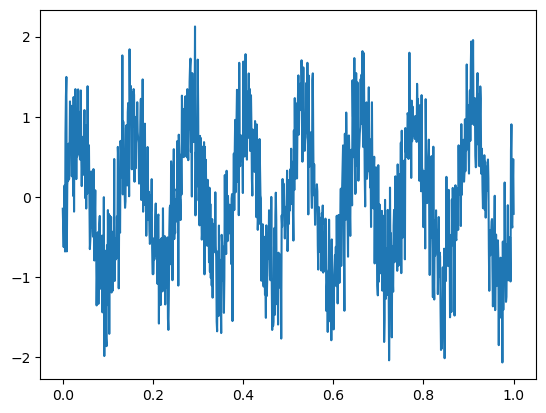

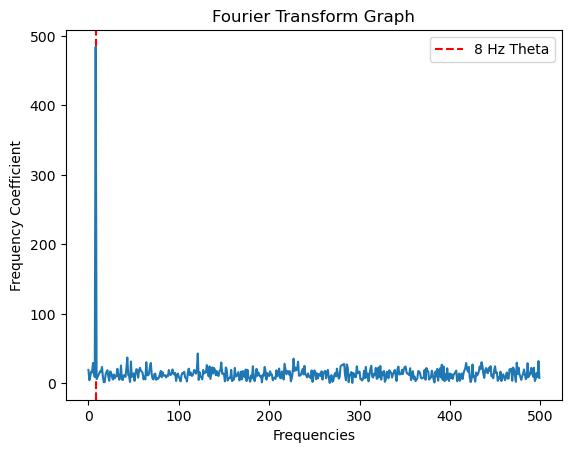

In [1]:
# Week 5 — Neural Signal Analysis & Statistical Modeling

## 1. Gene GC Content Analysis
# [tu código de gc_array, estadísticas NumPy, histograma con puntos reales]

import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO
from adjustText import adjust_text


def full_analysis(sequence):
    genes = []

    for record in SeqIO.parse(sequence, "fasta"):

        gen = {
            "id": record.id,
            "length": len(record.seq),
            "gc": (record.seq.count('G') + record.seq.count('C')) / len(record.seq) * 100,
            "sequence": record.seq
        }

        genes.append(gen)

    return genes


def make_numpy_array(genes):
    gc_list = []

    for x in genes:
        gc_list.append(x["gc"])

    gc_array = np.array(gc_list)

    return gc_array


genes = full_analysis("brain_genes.fasta")

gc_array = make_numpy_array(genes)

mean = np.mean(gc_array)
standard_deviation = np.std(gc_array)
max_value = np.max(gc_array)
min_value = np.min(gc_array)

average = np.average(gc_array)

neural_entropy = np.random.normal(mean, standard_deviation, 1000)

plt.hist(neural_entropy, bins=30, color='blue')

plt.title("Neural simulations of GC based on SD")
plt.xlabel("GC percentage")
plt.ylabel("Number of simulations that ended up in that GC")
plt.axvline(mean, color='red', linestyle='--', label="GC mean")
plt.axvline(average, color='red', linestyle='--', label="Average")

y_values = np.full(len(gc_array), 80)
plt.scatter(gc_array, y_values)
texts = []

for gen in genes:

    text = plt.annotate(
        text=gen["id"],
        xy=(gen["gc"], 80)
    )

    texts.append(text)
adjust_text(texts)
plt.legend()
plt.show()
print(f"Mean: {mean}")
print(f"The standard deviation is around {standard_deviation} points")

print(f"The max gc is: {max_value}")
print(f"The min gc is: {min_value}")

print(type(gc_array))
print(gc_array.dtype)

print(gc_array)

## 2. Neural Signal Simulation  
# [señal theta, ruido, actual_brain_accurate_wave]

import numpy as np
from scipy import fft
import matplotlib.pyplot as plt
from Bio import SeqIO


time= np.linspace(0, 1, 1000)   
alpha_brainwave= np.sin(2 * np.pi * 8 * time)
noise=np.random.normal(0, .9, 1000)
actual_brain_accurate_wave=alpha_brainwave+noise

plt.figure()
plt.plot(time, actual_brain_accurate_wave)
plt.xlabel('Frequencies')
plt.ylabel('ocilation size')
plt.title('Brainwave simulation')
plt.show()


## 3. Frequency Analysis — Fourier Transform
# [FFT, espectro, pico en 8 Hz]
import numpy as np
from scipy import fft
import matplotlib.pyplot as plt
from Bio import SeqIO



time= np.linspace(0, 1, 1000)   
alpha_brainwave= np.sin(2 * np.pi * 8 * time)
noise=np.random.normal(0, .5, 1000)
actual_brain_accurate_wave=alpha_brainwave+noise
frequencias= fft.fftfreq(len(actual_brain_accurate_wave),1/1000)[:500]
frequency_coeficients= np.abs(fft.fft(actual_brain_accurate_wave))[:500]



plt.figure()
plt.plot(time, actual_brain_accurate_wave)
plt.figure()
plt.axvline(x=8, color='red', linestyle='--', label='8 Hz Theta')
plt.legend()
plt.xlabel('Frequencies')
plt.ylabel('Frequency Coefficient')
plt.title('Fourier Transform Graph')
plt.plot(frequencias,frequency_coeficients)
plt.show()
